Loading packages and Data

In [1]:
library(minfi)

data_dir <- '/home/ethan-xiao/food-allergy-biomarkers/data'
rgSet <- readRDS(file.path(data_dir, 'rgSet_resting.rds'))
rgSet

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘pac

class: RGChannelSet 
dim: 1051539 43 
metadata(0):
assays(2): Green Red
rownames(1051539): 1600101 1600111 ... 99810990 99810992
rowData names(0):
colnames(43): GSM5695306_204088100082_R07C01
  GSM5695308_204088100082_R05C01 ... GSM5695390_204273120066_R01C01
  GSM5695392_204273120073_R06C01
colData names(10): gsm indiidual ... Basename filenames
Annotation
  array: IlluminaHumanMethylationEPIC
  annotation: ilm10b4.hg19

In [2]:
detP <- detectionP(rgSet) #Computing effects
dim(detP)

Loading required package: IlluminaHumanMethylationEPICmanifest



[1] 865859     43

In [3]:
warnings()
setdiff(rownames(rgSet), rownames(detP)) |> length() #No probes left behind

[1] 1051539

In [4]:
head(rownames(rgSet))
head(rownames(detP))

[1] "1600101" "1600111" "1600115" "1600123" "1600131" "1600135"

[1] "cg18478105" "cg09835024" "cg14361672" "cg01763666" "cg12950382"
[6] "cg02115394"

In [5]:
mean_detP <- colMeans(detP) #Making sure individual samples don't just generally have significant p-values
mean_detP

GSM5695306_204088100082_R07C01 GSM5695308_204088100082_R05C01 
                  0.0003179890                   0.0002476080 
GSM5695310_204281260061_R01C01 GSM5695312_204273120074_R06C01 
                  0.0002444764                   0.0002161249 
GSM5695314_204273120073_R02C01 GSM5695316_204281260061_R07C01 
                  0.0002734079                   0.0003347501 
GSM5695318_204088100071_R04C01 GSM5695320_204281260063_R01C01 
                  0.0002290755                   0.0008869530 
GSM5695322_204088100053_R06C01 GSM5695324_204273120074_R08C01 
                  0.0004273313                   0.0007573806 
GSM5695326_204281260060_R01C01 GSM5695328_204281260061_R05C01 
                  0.0002752553                   0.0006483410 
GSM5695330_204281260061_R04C01 GSM5695332_204273120066_R08C01 
                  0.0004985420                   0.0002984438 
GSM5695334_204281260063_R08C01 GSM5695336_204273120005_R07C01 
                  0.0004480628                   0.0004417041 
GSM5695338_204088100071_R01C01 GSM5695340_204273120074_R05C01 
                  0.0003049516                   0.0004608656 
GSM5695343_204273120068_R04C01 GSM5695345_204088100053_R03C01 
                  0.0008794693                   0.0003954346 
GSM5695347_204281260061_R08C01 GSM5695349_204281260060_R04C01 
                  0.0019823243                   0.0002207132 
GSM5695351_204273120074_R03C01 GSM5695353_204273120074_R02C01 
                  0.0003781132                   0.0004805024 
GSM5695355_204273120068_R06C01 GSM5695357_204273120066_R06C01 
                  0.0002346770                   0.0002669184 
GSM5695359_204273120074_R01C01 GSM5695360_204273120005_R06C01 
                  0.0003255004                   0.0003466336 
GSM5695362_204088100071_R08C01 GSM5695364_204281260043_R08C01 
                  0.0003111519                   0.0006991904 
GSM5695366_204088100071_R06C01 GSM5695368_204281260043_R05C01 
                  0.0002055750                   0.0003184216 
GSM5695372_204273120073_R05C01 GSM5695374_204281260043_R03C01 
                  0.0004790709                   0.0003476807 
GSM5695376_204281260063_R03C01 GSM5695378_204273120068_R01C01 
                  0.0004929247                   0.0001612885 
GSM5695380_204273120068_R03C01 GSM5695382_204088100082_R03C01 
                  0.0004263532                   0.0001261963 
GSM5695384_204281260063_R06C01 GSM5695386_204273120074_R04C01 
                  0.0002588390                   0.0004442147 
GSM5695388_204281260063_R05C01 GSM5695390_204273120066_R01C01 
                  0.0005102913                   0.0005633046 
GSM5695392_204273120073_R06C01 
                  0.0004745200

Filtering out Noise

In [6]:
detP_cg <- detP  
failed <- detP_cg > 0.01 #Strict filtering across samples 
failed_fraction <- rowMeans(failed)
probes_to_keep <- names(failed_fraction)[failed_fraction <= 0.01] #Strict filtering across data at large
length(probes_to_keep)

[1] 851103

In [7]:
saveRDS(detP, file.path(data_dir, 'detP.rds'))
saveRDS(probes_to_keep, file.path(data_dir, 'probes_to_keep.rds'))

Loading more tools

In [8]:
BiocManager::install("preprocessCore", configure.args = "--disable-threading", force = TRUE)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.3 (2026-03-11)

Installing package(s) 'preprocessCore'

Warning message in install.packages(...):
“installation of package ‘preprocessCore’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Old packages: 'bitops', 'DelayedArray', 'Matrix', 'S4Vectors', 'SparseArray',
  'stringi', 'XML'



In [9]:
library(minfi)
grSet <- preprocessFunnorm(rgSet)

[preprocessFunnorm] Background and dye bias correction with noob

Loading required package: IlluminaHumanMethylationEPICanno.ilm10b4.hg19

[preprocessFunnorm] Mapping to genome

[preprocessFunnorm] Quantile extraction

[preprocessFunnorm] Normalization



In [11]:
Sys.getenv("OPENBLAS_NUM_THREADS")

[1] "1"

Normalization of data (beta and m values)

In [12]:
data_dir <- '/home/ethan-xiao/food-allergy-biomarkers/data'
rgSet <- readRDS(file.path(data_dir, 'rgSet_resting.rds'))

grSet <- preprocessFunnorm(rgSet)
grSet

[preprocessFunnorm] Background and dye bias correction with noob

[preprocessFunnorm] Mapping to genome

[preprocessFunnorm] Quantile extraction

[preprocessFunnorm] Normalization



class: GenomicRatioSet 
dim: 865859 43 
metadata(0):
assays(2): Beta CN
rownames(865859): cg14817997 cg26928153 ... cg07587934 cg16855331
rowData names(0):
colnames(43): GSM5695306_204088100082_R07C01
  GSM5695308_204088100082_R05C01 ... GSM5695390_204273120066_R01C01
  GSM5695392_204273120073_R06C01
colData names(13): gsm indiidual ... yMed predictedSex
Annotation
  array: IlluminaHumanMethylationEPIC
  annotation: ilm10b4.hg19
Preprocessing
  Method: NA
  minfi version: NA
  Manifest version: NA

In [13]:
saveRDS(grSet, file.path(data_dir, 'grSet_funnorm.rds'))

In [14]:
table(predicted = grSet$predictedSex, reported = grSet$Sex) #Checking data quality

         reported
predicted  F  M
        F 18  0
        M  0 25

In [16]:
library(minfi)

data_dir <- '/home/ethan-xiao/food-allergy-biomarkers/data'
grSet <- readRDS(file.path(data_dir, 'grSet_funnorm.rds'))
probes_to_keep <- readRDS(file.path(data_dir, 'probes_to_keep.rds'))

dim(grSet)
length(probes_to_keep)

[1] 865859     43

[1] 851103

In [17]:
grSet_filtered <- grSet[probes_to_keep, ] #Applying probe filter
dim(grSet_filtered)

[1] 851103     43

In [18]:
betas <- getBeta(grSet_filtered) #Getting beta values
dim(betas)
betas[1:5, 1:3]

[1] 851103     43

,GSM5695306_204088100082_R07C01,GSM5695308_204088100082_R05C01,GSM5695310_204281260061_R01C01
cg18478105,0.01739592,0.01630083,0.01943077
cg09835024,0.03023710,0.03268231,0.03546459
cg14361672,0.94382358,0.94262099,0.92054634
cg01763666,0.65537110,0.44667683,0.50177526
cg12950382,0.68399288,0.80467783,0.78093606


In [19]:
saveRDS(betas, file.path(data_dir, 'betas_filtered.rds'))

In [20]:
mVals <- getM(grSet_filtered) #Getting M-values
dim(mVals)
mVals[1:3, 1:3]

[1] 851103     43

,GSM5695306_204088100082_R07C01,GSM5695308_204088100082_R05C01,GSM5695310_204281260061_R01C01
cg18478105,-5.819789,-5.915200,-5.657205
cg09835024,-5.003240,-4.887408,-4.765383
cg14361672,4.070481,4.038083,3.534305


Checking for duplicates and variants

In [21]:
table(table(grSet_filtered$indiidual))


 1  3 
40  1 

In [22]:
dup_ind <- names(ind_counts)[ind_counts > 1]

ind_counts <- table(grSet_filtered$indiidual) #Checking which one is off/same id in multiple samples
dup_ind <- names(ind_counts)[ind_counts > 1]
dup_ind

grSet_filtered@colData[grSet_filtered$indiidual == dup_ind, c('gsm', 'indiidual', 'allergy_status', 'Sex')]

[1] "SFA_1"

DataFrame with 3 rows and 4 columns
                                       gsm   indiidual       allergy_status
                               <character> <character>          <character>
GSM5695306_204088100082_R07C01  GSM5695306       SFA_1 single_food_allergic
GSM5695320_204281260063_R01C01  GSM5695320       SFA_1 single_food_allergic
GSM5695343_204273120068_R04C01  GSM5695343       SFA_1 single_food_allergic
                                       Sex
                               <character>
GSM5695306_204088100082_R07C01           F
GSM5695320_204281260063_R01C01           F
GSM5695343_204273120068_R04C01           M

In [23]:
table(grSet_filtered$allergy_status, grSet_filtered$Sex)

                      
                       F M
  control              6 9
  multi_food_allergic  7 8
  single_food_allergic 5 8

Checking whether to include more covariates

In [24]:
sample_names <- colnames(mVals)
chip <- sub('^GSM\\d+_(\\d+)_.*$', '\\1', sample_names) #Possible source of variation
position <- sub('^.*_(R\\d+C\\d+)$', '\\1', sample_names) #Possible source of variation

table(chip)
table(position)

chip
204088100053 204088100071 204088100082 204273120005 204273120066 204273120068 
           2            4            3            2            3            4 
204273120073 204273120074 204281260043 204281260060 204281260061 204281260063 
           3            7            3            2            5            5 

position
R01C01 R02C01 R03C01 R04C01 R05C01 R06C01 R07C01 R08C01 
     7      2      6      5      6      8      3      6 

In [25]:
pca <- prcomp(t(mVals), scale. = FALSE) #Cheking for the different axes of variation

var_explained <- pca$sdev^2 / sum(pca$sdev^2)
round(var_explained[1:5] * 100, 1)

ERROR: Error in svd(x, nu = 0, nv = k): infinite or missing values in 'x'


In [1]:
sum(is.infinite(mVals)) #Resolving pca error 
sum(is.na(mVals))

ERROR: Error: object 'mVals' not found


In [4]:
bad_probes <- apply(mVals, 1, function(x) any(is.infinite(x) | is.na(x)))
mVals_clean <- mVals[!bad_probes, ] #Filtering them out

ERROR: Error: object 'mVals' not found


In [28]:
pca <- prcomp(t(mVals_clean), scale. = FALSE) #Running pca again w/o the bad probes

var_explained <- pca$sdev^2 / sum(pca$sdev^2)
round(var_explained[1:5] * 100, 1)

[1] 22.3 15.6  2.8  2.5  2.4

In [29]:
sample_names <- colnames(mVals_clean) #Testing which 
chip <- sub('^GSM\\d+_(\\d+)_.*$', '\\1', sample_names)
position <- sub('^.*_(R\\d+C\\d+)$', '\\1', sample_names)

table(chip)

chip
204088100053 204088100071 204088100082 204273120005 204273120066 204273120068 
           2            4            3            2            3            4 
204273120073 204273120074 204281260043 204281260060 204281260061 204281260063 
           3            7            3            2            5            5 

In [30]:
pcs <- pca$x[, 1:5] #Testing principle components againts possible covariates

summary(aov(pcs[,1] ~ factor(chip)))
summary(aov(pcs[,1] ~ factor(grSet_filtered$allergy_status)))
summary(aov(pcs[,1] ~ factor(grSet_filtered$Sex)))

             Df Sum Sq Mean Sq F value Pr(>F)
factor(chip) 11 417997   38000    1.19  0.334
Residuals    31 990225   31943               

                                      Df  Sum Sq Mean Sq F value Pr(>F)
factor(grSet_filtered$allergy_status)  2   13754    6877   0.197  0.822
Residuals                             40 1394469   34862               

                           Df  Sum Sq Mean Sq F value Pr(>F)
factor(grSet_filtered$Sex)  1   41790   41790   1.254  0.269
Residuals                  41 1366432   33328               

In [31]:
summary(aov(pcs[,2] ~ factor(chip))) #More checks
summary(aov(pcs[,2] ~ factor(grSet_filtered$allergy_status)))
summary(aov(pcs[,2] ~ factor(grSet_filtered$Sex)))

             Df Sum Sq Mean Sq F value Pr(>F)  
factor(chip) 11 439171   39925   2.278 0.0353 *
Residuals    31 543426   17530                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                                      Df Sum Sq Mean Sq F value Pr(>F)
factor(grSet_filtered$allergy_status)  2   1784     892   0.036  0.964
Residuals                             40 980813   24520               

                           Df Sum Sq Mean Sq F value Pr(>F)    
factor(grSet_filtered$Sex)  1 949913  949913    1192 <2e-16 ***
Residuals                  41  32684     797                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [32]:
summary(aov(pcs[,2] ~ factor(grSet_filtered$Sex) + factor(chip)))

                           Df Sum Sq Mean Sq  F value Pr(>F)    
factor(grSet_filtered$Sex)  1 949913  949913 1177.454 <2e-16 ***
factor(chip)               11   8482     771    0.956  0.505    
Residuals                  30  24203     807                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [35]:
sex_probes <- annotation$Name[annotation$chr %in% c('chrX', 'chrY')]
length(sex_probes)

keep_autosomal <- !(rownames(mVals_clean) %in% sex_probes) #Filtering out sex probes
mVals_auto <- mVals_clean[keep_autosomal, ]
dim(mVals_auto)

[1] 18506

[1] 832597     43

In [36]:
pca_auto <- prcomp(t(mVals_auto), scale. = FALSE) #Checking covariate effects after removing sex probes

var_auto <- pca_auto$sdev^2 / sum(pca_auto$sdev^2)
round(var_auto[1:5] * 100, 1)

pcs_auto <- pca_auto$x[, 1:5]

summary(aov(pcs_auto[,1] ~ factor(grSet_filtered$Sex)))
summary(aov(pcs_auto[,1] ~ factor(chip)))
summary(aov(pcs_auto[,1] ~ factor(grSet_filtered$allergy_status)))

[1] 25.8  3.3  2.9  2.9  2.7

                           Df  Sum Sq Mean Sq F value Pr(>F)
factor(grSet_filtered$Sex)  1    5707    5707   0.171  0.681
Residuals                  41 1366797   33337               

             Df Sum Sq Mean Sq F value Pr(>F)
factor(chip) 11 420491   38226   1.245  0.301
Residuals    31 952013   30710               

                                      Df  Sum Sq Mean Sq F value Pr(>F)
factor(grSet_filtered$allergy_status)  2   12309    6154   0.181  0.835
Residuals                             40 1360195   34005               

In [37]:
colnames(grSet_filtered@colData)

[1] "gsm"                     "indiidual"              
 [3] "cell.type"               "stimulation_status"     
 [5] "Sex"                     "allergy_status"         
 [7] "allergy_status_detailed" "activation_status"      
 [9] "Basename"                "filenames"              
[11] "xMed"                    "yMed"                   
[13] "predictedSex"

Covariate Investigation using Raw IDAT files

In [38]:
library(illuminaio)

idat_dir <- '/home/ethan-xiao/food-allergy-biomarkers/data/GSE189148_idats'

probe_count <- sapply(grSet_filtered$gsm, function(g) {
  f <- list.files(idat_dir, pattern = paste0('^', g, '_.*_Grn\\.idat\\.gz$'), full.names = TRUE)
  readIDAT(f)$nSNPsRead
})

table(probe_count)

probe_count
1051815 1051943 
      9      34 

In [39]:
summary(aov(pcs_auto[,1] ~ factor(probe_count)))

                    Df  Sum Sq Mean Sq F value Pr(>F)  
factor(probe_count)  1  126294  126294   4.155  0.048 *
Residuals           41 1246209   30395                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [40]:
summary(aov(pcs_auto[,1] ~ factor(position)))

                 Df  Sum Sq Mean Sq F value Pr(>F)
factor(position)  7  317136   45305   1.502  0.199
Residuals        35 1055367   30153               

In [41]:
example_file <- list.files(idat_dir, pattern = '_Grn\\.idat\\.gz$', full.names = TRUE)[1]
idat <- readIDAT(example_file)
idat$RunInfo[1:10, ] #Checking to see the appropriate filter name

RunTime,BlockType,BlockPars,BlockCode,CodeVersion
1/13/2020 5:27:41 AM,Decoding,CallsToUsed=2849996|CallsToUnused=2173|CallsToInvalid=47299,AutoDecode,2.6.2
8/28/2020 4:01:57 PM,Scan,sherlockID=N0829|ScannerID=N0829|Username=Illumina|FPGAVersion=4.0.20|SoftwareAppication=iScan Control Software|SoftwareVersion=4.0.0.147,iScan Control Software,4.0.0.147
8/28/2020 4:01:57 PM,Register,Algorithm=StandardGeneric,iScan Control Software,4.0.0.147
8/28/2020 4:01:57 PM,Extract,Algorithm=StandardWithBackground,iScan Control Software,4.0.0.147
1/13/2020 5:29:19 AM,Decoding,CallsToUsed=2826741|CallsToUnused=2051|CallsToInvalid=44962,AutoDecode,2.6.2
8/28/2020 4:02:16 PM,Scan,sherlockID=N0829|ScannerID=N0829|Username=Illumina|FPGAVersion=4.0.20|SoftwareAppication=iScan Control Software|SoftwareVersion=4.0.0.147,iScan Control Software,4.0.0.147
8/28/2020 4:02:16 PM,Register,Algorithm=StandardGeneric,iScan Control Software,4.0.0.147
8/28/2020 4:02:16 PM,Extract,Algorithm=StandardWithBackground,iScan Control Software,4.0.0.147
1/13/2020 5:28:49 AM,Decoding,CallsToUsed=2821015|CallsToUnused=2303|CallsToInvalid=49635,AutoDecode,2.6.2
8/28/2020 4:02:37 PM,Scan,sherlockID=N0829|ScannerID=N0829|Username=Illumina|FPGAVersion=4.0.20|SoftwareAppication=iScan Control Software|SoftwareVersion=4.0.0.147,iScan Control Software,4.0.0.147


In [42]:
scan_info <- sapply(grSet_filtered$gsm, function(g) {
  f <- list.files(idat_dir, pattern = paste0('^', g, '_.*_Grn\\.idat\\.gz$'), full.names = TRUE)
  ri <- readIDAT(f)$RunInfo
  scan_rows <- ri[trimws(ri[, 'BlockType']) == 'Scan', ]
  scan_rows[1, 'RunTime']
})

scan_date <- as.Date(sapply(strsplit(scan_info, ' '), `[`, 1), format = '%m/%d/%Y')
table(scan_date)

scan_date
2020-08-28 2020-09-01 
        34          9 

In [43]:
summary(aov(pcs_auto[,1] ~ factor(scan_date))) #Checking potential combined technical variation

                  Df  Sum Sq Mean Sq F value Pr(>F)  
factor(scan_date)  1  126294  126294   4.155  0.048 *
Residuals         41 1246209   30395                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [44]:
table(scan_date, probe_count)

            probe_count
scan_date    1051815 1051943
  2020-08-28       0      34
  2020-09-01       9       0

In [45]:
batch <- factor(scan_date)

In [46]:
library(limma)

group <- factor(grSet_filtered$allergy_status)
batch <- factor(scan_date)

design <- model.matrix(~ 0 + group + batch) #Removing intercept
colnames(design)


Attaching package: ‘limma’


The following object is masked from ‘package:BiocGenerics’:

    plotMA




[1] "groupcontrol"              "groupmulti_food_allergic" 
[3] "groupsingle_food_allergic" "batch2020-09-01"

In [47]:
individual <- factor(grSet_filtered$indiidual)

corfit <- duplicateCorrelation(mVals_auto, design, block = individual) #Checking for duplicates using M-values
corfit$consensus.correlation

In [48]:
rep_samples <- colnames(mVals_auto)[grSet_filtered$indiidual == dup_ind]

cor(mVals_auto[, rep_samples]) #Checking numerical corelation
mean(cor(mVals_auto[, 1:10])[upper.tri(diag(10))]) #COmparing to general correlation

,GSM5695306_204088100082_R07C01,GSM5695320_204281260063_R01C01,GSM5695343_204273120068_R04C01
GSM5695306_204088100082_R07C01,1.0000000,0.9843931,0.9719768
GSM5695320_204281260063_R01C01,0.9843931,1.0000000,0.9769930
GSM5695343_204273120068_R04C01,0.9719768,0.9769930,1.0000000


[1] 0.9863812

In [49]:
library(minfi)
rgSet <- readRDS(file.path(data_dir, 'rgSet_resting.rds'))
snps <- getSnpBeta(rgSet)
round(cor(snps[, rep_samples]), 3) #Now checking SNP correlation (same at birth, doesn't change)
round(cor(snps[, 1:6]), 3)

,GSM5695306_204088100082_R07C01,GSM5695320_204281260063_R01C01,GSM5695343_204273120068_R04C01
GSM5695306_204088100082_R07C01,1.000,0.373,0.272
GSM5695320_204281260063_R01C01,0.373,1.000,0.298
GSM5695343_204273120068_R04C01,0.272,0.298,1.000


,GSM5695306_204088100082_R07C01,GSM5695308_204088100082_R05C01,GSM5695310_204281260061_R01C01,GSM5695312_204273120074_R06C01,GSM5695314_204273120073_R02C01,GSM5695316_204281260061_R07C01
GSM5695306_204088100082_R07C01,1.000,0.231,0.281,0.328,0.184,0.037
GSM5695308_204088100082_R05C01,0.231,1.000,0.234,0.216,0.008,0.019
GSM5695310_204281260061_R01C01,0.281,0.234,1.000,0.205,0.237,0.105
GSM5695312_204273120074_R06C01,0.328,0.216,0.205,1.000,0.285,0.117
GSM5695314_204273120073_R02C01,0.184,0.008,0.237,0.285,1.000,0.002
GSM5695316_204281260061_R07C01,0.037,0.019,0.105,0.117,0.002,1.000


In [50]:
rgSet_all <- read.metharray.exp(targets = read.csv(file.path(data_dir, 'GSE189148_sample_metadata.csv')), force = TRUE) #Using all samples as comparison to be extra sure
snps_all <- getSnpBeta(rgSet_all)

In [51]:
data_dir <- '/home/ethan-xiao/food-allergy-biomarkers/data'
targets_all <- read.csv(file.path(data_dir, 'GSE189148_sample_metadata.csv'),
                        stringsAsFactors = FALSE)

In [52]:
str(targets_all)
table(targets_all$indiidual)

'data.frame':	88 obs. of  9 variables:
 $ gsm                    : chr  "GSM5695305" "GSM5695306" "GSM5695307" "GSM5695308" ...
 $ indiidual              : chr  "SFA_1" "SFA_1" "SFA_2" "SFA_2" ...
 $ cell.type              : chr  "CD4 T cells" "CD4 T cells" "CD4 T cells" "CD4 T cells" ...
 $ stimulation_status     : chr  "S" "U" "S" "U" ...
 $ Sex                    : chr  "F" "F" "F" "F" ...
 $ allergy_status         : chr  "single_food_allergic" "single_food_allergic" "single_food_allergic" "single_food_allergic" ...
 $ allergy_status_detailed: chr  "PEANUT ONLY" "PEANUT ONLY" "PEANUT ONLY" "PEANUT ONLY" ...
 $ activation_status      : chr  "DNAme" "DNAme" "DNAme" "DNAme" ...
 $ Basename               : chr  "../data/GSE189148_idats/GSM5695305_204273120005_R02C01" "../data/GSE189148_idats/GSM5695306_204088100082_R07C01" "../data/GSE189148_idats/GSM5695307_204088100053_R08C01" "../data/GSE189148_idats/GSM5695308_204088100082_R05C01" ...



 MFA_1 MFA_10 MFA_11 MFA_12 MFA_13 MFA_14 MFA_15  MFA_2  MFA_3  MFA_4  MFA_5 
     2      2      2      2      2      2      2      2      2      2      2 
 MFA_6  MFA_7  MFA_8  MFA_9   NA_1  NA_10  NA_11  NA_12  NA_13  NA_14  NA_15 
     2      2      2      2      2      2      2      1      2      2      2 
 NA_16  NA_17   NA_2   NA_3   NA_4   NA_5   NA_6   NA_7   NA_8   NA_9  SFA_1 
     2      2      2      2      2      2      1      2      2      2      4 
SFA_10 SFA_11 SFA_12 SFA_13  SFA_2  SFA_3  SFA_4  SFA_5  SFA_6  SFA_7  SFA_8 
     1      2      2      2      2      2      3      1      2      1      2 
 SFA_9 
     2 

In [53]:
table(targets_all$indiidual, targets_all$stimulation_status)

        
         S U
  MFA_1  1 1
  MFA_10 1 1
  MFA_11 1 1
  MFA_12 1 1
  MFA_13 1 1
  MFA_14 1 1
  MFA_15 1 1
  MFA_2  1 1
  MFA_3  1 1
  MFA_4  1 1
  MFA_5  1 1
  MFA_6  1 1
  MFA_7  1 1
  MFA_8  1 1
  MFA_9  1 1
  NA_1   1 1
  NA_10  1 1
  NA_11  1 1
  NA_12  1 0
  NA_13  1 1
  NA_14  1 1
  NA_15  1 1
  NA_16  1 1
  NA_17  1 1
  NA_2   1 1
  NA_3   1 1
  NA_4   1 1
  NA_5   1 1
  NA_6   1 0
  NA_7   1 1
  NA_8   1 1
  NA_9   1 1
  SFA_1  1 3
  SFA_10 1 0
  SFA_11 1 1
  SFA_12 1 1
  SFA_13 1 1
  SFA_2  1 1
  SFA_3  1 1
  SFA_4  2 1
  SFA_5  1 0
  SFA_6  1 1
  SFA_7  0 1
  SFA_8  1 1
  SFA_9  1 1

Reconciling Dataset Inconsistencies

In [54]:
library(minfi)
data_dir <- '/home/ethan-xiao/food-allergy-biomarkers/data'

targets_all <- read.csv(file.path(data_dir, 'GSE189148_sample_metadata.csv'),
                        stringsAsFactors = FALSE)

rgSet_all <- read.metharray.exp(targets = targets_all, force = TRUE)
snps_all  <- getSnpBeta(rgSet_all)

saveRDS(snps_all, file.path(data_dir, 'snps_all.rds'))
dim(snps_all)

[1] 59 88


Attaching package: ‘dplyr’


The following object is masked from ‘package:minfi’:

    combine


The following objects are masked from ‘package:Biostrings’:

    collapse, intersect, setdiff, setequal, union


The following object is masked from ‘package:XVector’:

    slice


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:Seqinfo’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, setequal, union


The following object is masked from ‘package:generics’:

    explai

,a,b,ind_a,ind_b,stim_a,stim_b,same_label,r
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<dbl>
GSM5695317_204273120073_R07C011,GSM5695317_204273120073_R07C01,GSM5695319_204088100082_R01C01,SFA_4,SFA_4,S,S,TRUE,0.1153831
GSM5695318_204088100071_R04C01,GSM5695318_204088100071_R04C01,GSM5695319_204088100082_R01C01,SFA_4,SFA_4,U,S,TRUE,0.1368868
GSM5695305_204273120005_R02C0137,GSM5695305_204273120005_R02C01,GSM5695343_204273120068_R04C01,SFA_1,SFA_1,S,U,TRUE,0.2564978
GSM5695306_204088100082_R07C0136,GSM5695306_204088100082_R07C01,GSM5695343_204273120068_R04C01,SFA_1,SFA_1,U,U,TRUE,0.2721204
GSM5695320_204281260063_R01C0122,GSM5695320_204281260063_R01C01,GSM5695343_204273120068_R04C01,SFA_1,SFA_1,U,U,TRUE,0.2984888
GSM5695305_204273120005_R02C0114,GSM5695305_204273120005_R02C01,GSM5695320_204281260063_R01C01,SFA_1,SFA_1,S,U,TRUE,0.3261209
GSM5695306_204088100082_R07C0113,GSM5695306_204088100082_R07C01,GSM5695320_204281260063_R01C01,SFA_1,SFA_1,U,U,TRUE,0.3730499
GSM5695350_204088100071_R02C01,GSM5695350_204088100071_R02C01,GSM5695351_204273120074_R03C01,NA_8,NA_8,S,U,TRUE,0.9687056
GSM5695363_204281260060_R03C01,GSM5695363_204281260060_R03C01,GSM5695364_204281260043_R08C01,NA_10,NA_10,S,U,TRUE,0.9813763


,a,b,ind_a,ind_b,stim_a,stim_b,same_label,r
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<dbl>
GSM5695319_204088100082_R01C01,GSM5695319_204088100082_R01C01,GSM5695320_204281260063_R01C01,SFA_4,SFA_1,S,U,FALSE,0.9894501
GSM5695342_204281260063_R02C01,GSM5695342_204281260063_R02C01,GSM5695343_204273120068_R04C01,SFA_5,SFA_1,S,U,FALSE,0.9889975


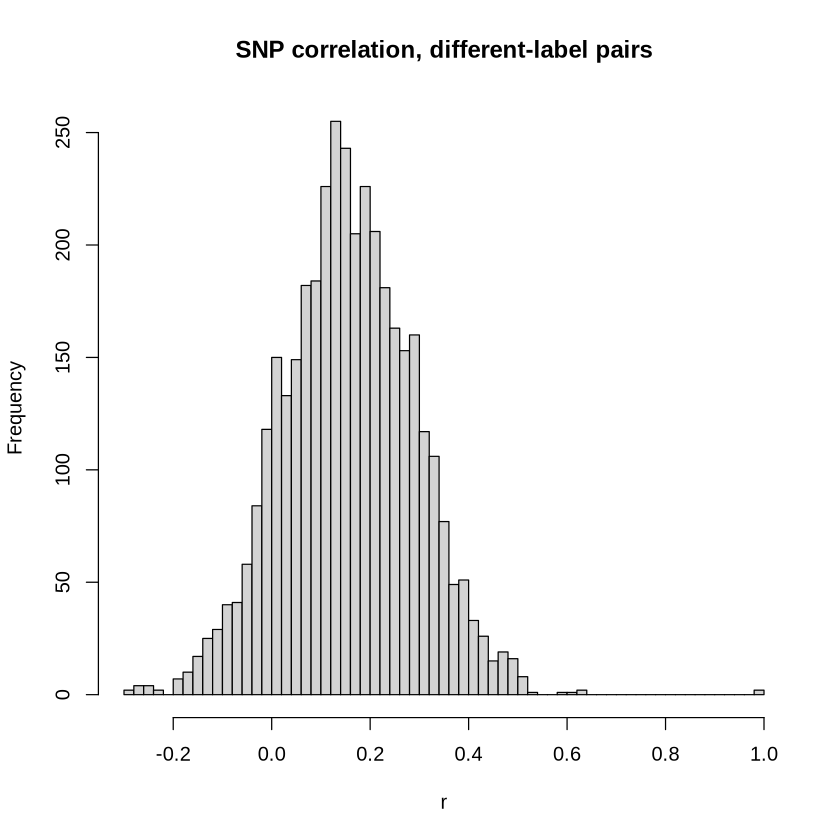

In [55]:
library(dplyr)

snps_all <- readRDS(file.path(data_dir, 'snps_all.rds'))

#match metadata rows to matrix columns
targets_all$col_id <- basename(targets_all$Basename)
stopifnot(all(colnames(snps_all) %in% targets_all$col_id))

lookup <- setNames(targets_all$indiidual, targets_all$col_id)
stim   <- setNames(targets_all$stimulation_status, targets_all$col_id)

#every pair
ids   <- colnames(snps_all)
pairs <- combn(ids, 2, simplify = FALSE)

res <- do.call(rbind, lapply(pairs, function(p) { #Checking all signals of duplication
  data.frame(
    a = p[1], b = p[2],
    ind_a = lookup[p[1]], ind_b = lookup[p[2]],
    stim_a = stim[p[1]],  stim_b = stim[p[2]],
    same_label = lookup[p[1]] == lookup[p[2]],
    r = cor(snps_all[, p[1]], snps_all[, p[2]], use = "pairwise.complete.obs"),
    stringsAsFactors = FALSE
  )
}))

saveRDS(res, file.path(data_dir, 'snp_pairwise.rds'))

#distribution check 
hist(res$r[!res$same_label], breaks = 50,
     main = "SNP correlation, different-label pairs", xlab = "r")

#find the worst out of the predicted same pairs
res %>% filter(same_label) %>% arrange(r) %>% head(20)

#high correlation but different labels
res %>% filter(!same_label, r > 0.90) %>% arrange(desc(r))

This cell was run successfully at an earlier point, producing `snp_pairwise.rds`/`.csv` and `GSE189148_sample_metadata_snp_annotated.csv` (all present in the data folder). The version shown here contains a corrected syntax error (a missing closing bracket in the final `identity_note` assignment) found during a later review. The saved output files reflect the corrections listed in the code below: GSM5695343 and GSM5695320/GSM5695319 relabeled based on SNP correlation evidence (see `note` fields); labels were corrected in the metadata record but the underlying GEO sample labels were left unmodified.

In [1]:
#SNP-verified identity correction — GSE189148
#Labels left alone. Corrections recorded, not applied.


#Use generated evidence
saveRDS(res, file.path(data_dir, 'snp_pairwise.rds'))
write.csv(res, file.path(data_dir, 'snp_pairwise.csv'), row.names = FALSE)

png(file.path(data_dir, 'snp_correlation_distribution.png'),
    width = 900, height = 500)
par(mfrow = c(1, 2))
hist(res$r[!res$same_label], breaks = 50,
     main = "Different-label pairs", xlab = "SNP correlation")
hist(res$r[res$same_label], breaks = 50,
     main = "Same-label pairs", xlab = "SNP correlation")
dev.off()
par(mfrow = c(1, 1))

#Record corrections as a new column
targets_all$individual_snp_verified <- targets_all$indiidual
targets_all$identity_note <- NA_character_

corrections <- list(
  list(gsm = 'GSM5695343', new = 'SFA_5',
       note = 'Deposited as SFA_1. SNP r=0.989 with GSM5695342 (SFA_5 S). Fills SFA_5 missing U.'),
  list(gsm = 'GSM5695320', new = 'UNK_1',
       note = 'Deposited as SFA_1. SNP r=0.989 with GSM5695319. True individual, not in metadata.'),
  list(gsm = 'GSM5695319', new = 'UNK_1',
       note = 'Deposited as SFA_4. SNP r=0.115-0.137 with other SFA_4 samples. Pairs with GSM5695320.')
)

for (cx in corrections) {
  i <- which(targets_all$gsm == cx$gsm)
  targets_all$individual_snp_verified[i] <- cx$new
  targets_all$identity_note[i] <- cx$note
}

#Flag unknowns
alone <- c('NA_6', 'NA_12', 'SFA_10', 'SFA_7')
targets_all$identity_note[targets_all$indiidual %in% alone] <-
  'Single sample; no within-individual pair available. Identity unverified.'

#Save alongside original
write.csv(targets_all,
          file.path(data_dir, 'GSE189148_sample_metadata_snp_annotated.csv'),
          row.names = FALSE)

table(targets_all$individual_snp_verified, targets_all$stimulation_status)

ERROR: Error: object 'data_dir' not found


In [3]:
data_dir <- '/home/ethan-xiao/food-allergy-biomarkers/data'
res_saved <- readRDS(file.path(data_dir, 'snp_pairwise.rds'))
head(res_saved)

annotated <- read.csv(file.path(data_dir, 'GSE189148_sample_metadata_snp_annotated.csv'))
table(annotated$individual_snp_verified, annotated$stimulation_status)
subset(annotated, gsm %in% c('GSM5695343', 'GSM5695320', 'GSM5695319'))

,a,b,ind_a,ind_b,stim_a,stim_b,same_label,r
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<dbl>
GSM5695305_204273120005_R02C01,GSM5695305_204273120005_R02C01,GSM5695306_204088100082_R07C01,SFA_1,SFA_1,S,U,TRUE,0.9929198
GSM5695305_204273120005_R02C011,GSM5695305_204273120005_R02C01,GSM5695307_204088100053_R08C01,SFA_1,SFA_2,S,S,FALSE,0.2129554
GSM5695305_204273120005_R02C012,GSM5695305_204273120005_R02C01,GSM5695308_204088100082_R05C01,SFA_1,SFA_2,S,U,FALSE,0.2159154
GSM5695305_204273120005_R02C013,GSM5695305_204273120005_R02C01,GSM5695309_204088100071_R03C01,SFA_1,MFA_1,S,S,FALSE,0.2866666
GSM5695305_204273120005_R02C014,GSM5695305_204273120005_R02C01,GSM5695310_204281260061_R01C01,SFA_1,MFA_1,S,U,FALSE,0.2777575
GSM5695305_204273120005_R02C015,GSM5695305_204273120005_R02C01,GSM5695311_204281260060_R02C01,SFA_1,MFA_2,S,S,FALSE,0.3291961


        
         S U
  MFA_1  1 1
  MFA_10 1 1
  MFA_11 1 1
  MFA_12 1 1
  MFA_13 1 1
  MFA_14 1 1
  MFA_15 1 1
  MFA_2  1 1
  MFA_3  1 1
  MFA_4  1 1
  MFA_5  1 1
  MFA_6  1 1
  MFA_7  1 1
  MFA_8  1 1
  MFA_9  1 1
  NA_1   1 1
  NA_10  1 1
  NA_11  1 1
  NA_12  1 0
  NA_13  1 1
  NA_14  1 1
  NA_15  1 1
  NA_16  1 1
  NA_17  1 1
  NA_2   1 1
  NA_3   1 1
  NA_4   1 1
  NA_5   1 1
  NA_6   1 0
  NA_7   1 1
  NA_8   1 1
  NA_9   1 1
  SFA_1  1 1
  SFA_10 1 0
  SFA_11 1 1
  SFA_12 1 1
  SFA_13 1 1
  SFA_2  1 1
  SFA_3  1 1
  SFA_4  1 1
  SFA_5  1 1
  SFA_6  1 1
  SFA_7  0 1
  SFA_8  1 1
  SFA_9  1 1
  UNK_1  1 1

,gsm,indiidual,cell.type,stimulation_status,Sex,allergy_status,allergy_status_detailed,activation_status,Basename,col_id,individual_snp_verified,identity_note
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
15,GSM5695319,SFA_4,CD4 T cells,S,F,single_food_allergic,PEANUT ONLY,DNAme,../data/GSE189148_idats/GSM5695319_204088100082_R01C01,GSM5695319_204088100082_R01C01,UNK_1,Deposited as SFA_4. SNP r=0.115-0.137 with other SFA_4 samples. Pairs with GSM5695320.
16,GSM5695320,SFA_1,CD4 T cells,U,F,single_food_allergic,PEANUT ONLY,DNAme,../data/GSE189148_idats/GSM5695320_204281260063_R01C01,GSM5695320_204281260063_R01C01,UNK_1,"Deposited as SFA_1. SNP r=0.989 with GSM5695319. True individual, not in metadata."
39,GSM5695343,SFA_1,CD4 T cells,U,M,single_food_allergic,PEANUT ONLY,DNAme,../data/GSE189148_idats/GSM5695343_204273120068_R04C01,GSM5695343_204273120068_R04C01,SFA_5,Deposited as SFA_1. SNP r=0.989 with GSM5695342 (SFA_5 S). Fills SFA_5 missing U.


- Loaded and quality-controlled 88 GSE189148 resting-state samples: detection p-values computed, funnorm normalization applied, probe filtering applied, beta/M-values extracted.
- PCA-based covariate screening tested chip, array position, sex, scan date, and allergy status against the top principal components; sex-linked probes were removed before re-testing to avoid sex driving the leading components.
- One known duplicate individual, flagged via declared metadata labels, was confirmed as a true technical replicate using SNP-fingerprint correlation.
- Extending the SNP check to all samples (not just the known duplicate) uncovered real mislabeling not caught by GEO's own metadata: GSM5695343 (deposited as SFA_1) is actually SFA_5, based on SNP correlation r=0.989 with a known SFA_5 sample; GSM5695320 and GSM5695319 (deposited as SFA_1 and SFA_4, respectively) are actually a matched pair belonging to a previously unlabeled individual (r=0.989 between them, but only r=0.115–0.137 with the samples they were originally grouped under).
- Corrections were recorded in a new `individual_snp_verified` column rather than overwriting the original GEO labels.
- Four samples (NA_6, NA_12, SFA_10, SFA_7) have no within-individual pair available and remain unverified by this method.
- The correction logic contained a syntax error (missing closing bracket) found during later review; the saved output files (`snp_pairwise.rds/csv`, `GSE189148_sample_metadata_snp_annotated.csv`) reflect an earlier successful run, not a re-verified run of the corrected code, due to time constraints.

Feeds into notebook 4 (GSE114134 analysis) and notebook 6 (cross-cohort DMR check), which use the SNP-verified sample identities.